In [91]:
from keras.datasets import mnist
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.linear_model import SGDClassifier
from sklearn.decomposition import PCA
from time import time
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

In [21]:
(train_X, train_y), (test_X, test_y) = mnist.load_data()

In [22]:
train_X.shape, test_X.shape

((60000, 28, 28), (10000, 28, 28))

In [23]:
train_X = train_X.reshape(60000,-1)
test_X = test_X.reshape(10000,-1)

In [24]:
train_X.shape, test_X.shape

((60000, 784), (10000, 784))

In [73]:
def train_model(model,train_X, train_y, test_X, test_y):
    if model=='rf':
        m = RandomForestClassifier()
    if model=='sgd':
        # m = SGDClassifier(learning_rate='constant',eta0=0.1)
        m = SGDClassifier()
    tic = time()
    m.fit(train_X, train_y)
    toc = time()
    acc = accuracy_score(test_y, m.predict(test_X))
    print(f"Time :  {round(toc-tic,1)}s")
    print(f"Accuracy :  {round(acc*100,1)} %")

In [35]:
train_model('rf',train_X, train_y, test_X, test_y)

Time :  43.9s
Accuracy :  97.1 %


In [36]:
train_model('sgd',train_X, train_y, test_X, test_y)

Time :  152.2s
Accuracy :  86.3 %


In [65]:
ss = StandardScaler()

In [66]:
train_X_ss = ss.fit_transform(train_X)
test_X_ss = ss.transform(test_X)

In [67]:
train_model('sgd', train_X_ss, train_y, test_X_ss, test_y)

Time :  328.5s
Accuracy :  90.0 %


In [71]:
train_model('sgd',train_X_ss, train_y, test_X_ss, test_y)

Time :  8.5s
Accuracy :  88.9 %


Post PCA

In [37]:
pca = PCA()

In [38]:
pca.fit(train_X)

PCA()

In [45]:
[e for e,i in enumerate(pca.explained_variance_ratio_.cumsum() > 0.95) if i==True][0]

153

In [46]:
train_X_pca = pca.fit_transform(train_X)

In [47]:
pca.explained_variance_ratio_.cumsum()[153]

0.9501960192613033

In [48]:
test_X_pca = pca.transform(test_X)

In [53]:
test_X_pca.shape

(10000, 784)

In [60]:
train_X_pca = train_X_pca[:,:153]
test_X_pca = test_X_pca[:,:153]

In [61]:
train_model('rf',train_X_pca, train_y, test_X_pca, test_y)

Time :  96.4s
Accuracy :  94.9 %


In [62]:
train_model('sgd',train_X_pca, train_y, test_X_pca, test_y)

Time :  30.3s
Accuracy :  88.6 %


---

In [76]:
x,y = train_X[:5000], train_y[:5000]

In [77]:
pca = PCA()

In [86]:
t = pca.fit_transform(x)[:,:2]

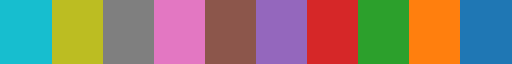

In [111]:
plt.cm.tab10

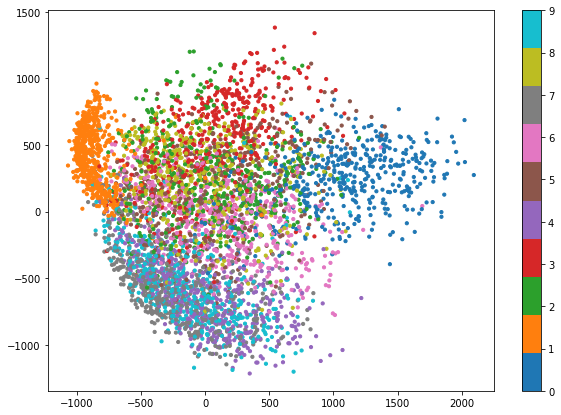

In [108]:
fig, ax = plt.subplots(1,1,figsize=(10,7))

# scatter = ax.scatter(x=t[:,0],y=t[:,1],c=y,cmap='tab10',s=10)
# plt.colorbar(scatter,ax=ax)

for i in range(t.shape[0]):
    ax.text(t[i, 0], t[i, 1], str(y[i]), fontsize=9, ha='center', va='center', color=plt.cm.tab10(y[i] / 10))
